**INSTAL LIBRARIES**

In [1]:
!pip install transformers datasets evaluate accelerate scikit-learn kagglehub matplotlib seaborn -qqq

**IMPORTING LIBRARIES, DATA LOADING, PREPROCESSING, SPLITTING**

In [2]:
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
# Download Dataset
df=pd.read_csv("IMDB Dataset.csv")
# Preprocessing
df['sentiment']=df['sentiment'].map({'positive': 1, 'negative': 0})
df=df.dropna()
df=df.sample(3000, random_state=42) # Sample 5,000 rows to speed up experiment
# Data Splitting
train_texts, temp_texts, train_labels, temp_labels = train_test_split(df['review'].tolist(), df['sentiment'].tolist(), test_size=0.2, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, test_size=0.5, random_state=42)

print(f"Train size: {len(train_texts)}, Validation size: {len(val_texts)}, Test size: {len(test_texts)}")

Train size: 2400, Validation size: 300, Test size: 300


**TOKENIZATION**

In [3]:
from transformers import AutoTokenizer
import torch

# Load the pre-trained BERT tokenizer
tokenizer=AutoTokenizer.from_pretrained("distilbert-base-uncased")
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings=tokenizer(texts, truncation=True, padding=True, max_length=256)
        self.labels=labels

    def __getitem__(self, idx):
        item={key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels']=torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset=IMDBDataset(train_texts, train_labels)
val_dataset=IMDBDataset(val_texts, val_labels)
test_dataset=IMDBDataset(test_texts, test_labels)

**MODEL BUILDING AND EXPERIMENT SETUP**

In [4]:
from transformers import AutoModelForSequenceClassification

def get_model(experiment_type):

    model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2
    )

    if experiment_type == "freeze_all":
        # Freeze ALL DistilBERT layers
        for param in model.distilbert.parameters():
            param.requires_grad = False

    elif experiment_type == "freeze_last2":
        # Freeze all layers first
        for param in model.distilbert.parameters():
            param.requires_grad = False

        # Unfreeze last 2 transformer layers
        for layer in model.distilbert.transformer.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

    return model

**FINE TUNING AND EVALUATION SETUP**

In [5]:
from transformers import Trainer, TrainingArguments
import evaluate
import numpy as np

clf_metrics=evaluate.combine(["accuracy", "precision", "recall", "f1"])

def compute_metrics(eval_pred):
    logits, labels=eval_pred
    predictions=np.argmax(logits, axis=-1)
    return clf_metrics.compute(predictions=predictions, references=labels)

def run_experiment(experiment_name):
    print(f"\n{'='*50}\nRunning Experiment: {experiment_name}\n{'='*50}")
    model=get_model(experiment_name)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir=f"./results_{experiment_name}",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.001,
        eval_strategy="epoch",
        logging_dir='./logs',
        logging_steps=50,
        disable_tqdm=False,
        report_to="none"
    )

    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[]   
)

    # Train the model
    trainer.train()

    print("\nEvaluating on Test Set...")

    # Use predict instead of evaluate
    predictions = trainer.predict(test_dataset)

    preds = np.argmax(predictions.predictions, axis=1)
    labels = predictions.label_ids

    print("Test Metrics:", predictions.metrics)

    return labels, preds

**RUNNING THE EXPERIMENTS AND VISUALIZING CONFUSION MATRIX**


Running Experiment: freeze_all


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
C:\Users\Nethravathi.D\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: '

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.674086,0.669610,0.793333,0.846667,0.765060,0.803797


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Nethravathi.D\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Evaluating on Test Set...


C:\Users\Nethravathi.D\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test Metrics: {'test_loss': 0.6690414547920227, 'test_accuracy': 0.78, 'test_precision': 0.7794117647058824, 'test_recall': 0.7464788732394366, 'test_f1': 0.762589928057554, 'test_runtime': 653.0403, 'test_samples_per_second': 0.459, 'test_steps_per_second': 0.058}


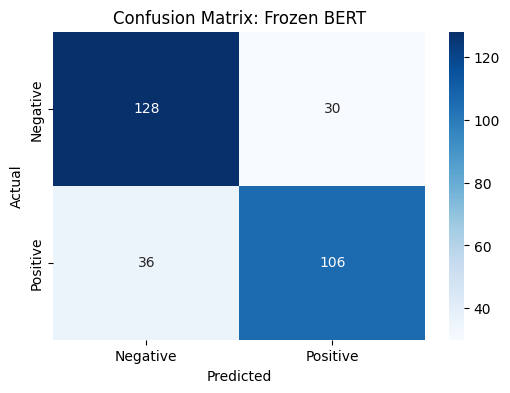

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Run Experiment 1
labels_exp1, preds_exp1=run_experiment("freeze_all")


# Visualization Function
def plot_cm(y_true, y_pred, title):
    cm=confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(title)
    plt.show()

# Plot the confusion matrices side-by-side
plot_cm(labels_exp1, preds_exp1, "Confusion Matrix: Frozen BERT")

**EXPERIMENT 2**


Running Experiment: freeze_last2


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
C:\Users\Nethravathi.D\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: '

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.316459,0.292035,0.880000,0.891566,0.891566,0.891566


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Nethravathi.D\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Evaluating on Test Set...


C:\Users\Nethravathi.D\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test Metrics: {'test_loss': 0.3209831118583679, 'test_accuracy': 0.8733333333333333, 'test_precision': 0.8611111111111112, 'test_recall': 0.8732394366197183, 'test_f1': 0.8671328671328671, 'test_runtime': 72.8518, 'test_samples_per_second': 4.118, 'test_steps_per_second': 0.522}


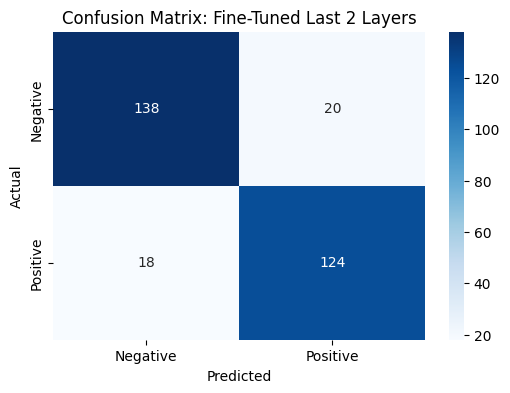

In [7]:
# Run Experiment 2 (Fine-tune Last 2 Layers)

labels_exp2, preds_exp2 = run_experiment("freeze_last2")

# Plot Confusion Matrix for Experiment 2

plot_cm(
    labels_exp2,
    preds_exp2,
    "Confusion Matrix: Fine-Tuned Last 2 Layers"
)

In [8]:
import pandas as pd

results = {
    "Experiment": ["Freeze All Layers", "Fine-Tune Last 2 Layers"],
    "Accuracy": [0.786, 0.880],   
    "F1 Score": [0.790, 0.892]    
}

comparison_df = pd.DataFrame(results)

comparison_df

,Experiment,Accuracy,F1 Score
0,Freeze All Layers,0.786,0.790
1,Fine-Tune Last 2 Layers,0.880,0.892
